### Imports and paths

In [ ]:
import sys
from pathlib import Path
from typing import Dict, Any, Tuple

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

ROOT = Path.cwd().resolve().parent  # es. se notebook è in /notebooks

if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths

paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

MODEL_SPECS = {
    "teacher_ft": {
        "display_name": "Teacher Fine-Tuned",
        "ckpt_path": CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000",   
        "threshold": 0.52,
        "bar_color": "#c0392b",   # rosso
        "cm_cmap": "Blues",       # blu/azzurro
    },
    "student_kd": {
        "display_name": "Student Distilled",
        "ckpt_path": CKPT_DIR / "tinybert_phase2" / "checkpoint-13000",  
        "threshold": 0.50,
        "bar_color": "#1f4e79",   # azzurro scuro
        "cm_cmap": "Reds",     # arancioni
    },
}



for k, v in MODEL_SPECS.items():
    print(f"{k}:")
    print("  path      =", v["ckpt_path"])
    print("  threshold =", v["threshold"])

Device: cuda
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints
teacher_ft:
  path      = C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
  threshold = 0.52
student_kd:
  path      = C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000
  threshold = 0.5


### Loading test set

In [2]:
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

required_cols = {"input_ids", "attention_mask", "labels"}
missing_cols = required_cols - set(test_ds.column_names)
if missing_cols:
    raise ValueError(f"Mancano colonne nel test set: {missing_cols}")

print("Test size:", len(test_ds))
print("Columns:", test_ds.column_names)
print("Sample keys:", test_ds[0].keys())

Test size: 31344
Columns: ['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids']
Sample keys: dict_keys(['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids'])


In [3]:
def make_infer_trainer(model_path: Path, per_device_eval_batch_size: int = 32) -> Trainer:
    """
    Crea un Trainer per sola inferenza da un checkpoint HF.
    """
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path)).to(device)
    model.eval()

    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir=str(CKPT_DIR / "_tmp_eval_graphs"),
        per_device_eval_batch_size=per_device_eval_batch_size,
        dataloader_num_workers=2,
        report_to="none",
        fp16=False,   
    )

    trainer = Trainer(
        model=model,
        args=args,
        data_collator=collator,
        tokenizer=tokenizer,
    )
    return trainer


def logits_to_positive_probs(predictions: np.ndarray) -> np.ndarray:
    """
    Converte predictions del Trainer in probabilità della classe positiva.
    Gestisce sia output [N,2] (softmax) sia [N] / [N,1] (sigmoid).
    """
    logits = torch.tensor(predictions)

    if logits.ndim == 2 and logits.shape[1] == 2:
        probs = torch.softmax(logits, dim=-1)[:, 1]
    elif logits.ndim == 1:
        probs = torch.sigmoid(logits)
    elif logits.ndim == 2 and logits.shape[1] == 1:
        probs = torch.sigmoid(logits[:, 0])
    else:
        raise ValueError(f"Shape logits non gestita: {tuple(logits.shape)}")

    return probs.cpu().numpy()


def predict_probs_and_labels(trainer: Trainer, ds) -> Tuple[np.ndarray, np.ndarray]:
    """
    Esegue predict() su ds e restituisce:
    - y_true (int)
    - probs classe positiva
    """
    pred_out = trainer.predict(ds)
    probs = logits_to_positive_probs(pred_out.predictions)
    y_true = pred_out.label_ids.astype(int)
    return y_true, probs


def compute_metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> Dict[str, float]:
    """
    Calcola metriche principali su probabilità + soglia.
    """
    y_pred = (probs >= threshold).astype(int)

    metrics = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, probs)),
        "PR-AUC": float(average_precision_score(y_true, probs)),
        "Pred Positive Rate": float(y_pred.mean()),
    }
    return metrics


def compute_confusion_matrix(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> np.ndarray:
    """
    Restituisce confusion matrix [[TN, FP], [FN, TP]].
    """
    y_pred = (probs >= threshold).astype(int)
    return confusion_matrix(y_true, y_pred, labels=[0, 1])


def row_normalize_cm(cm: np.ndarray) -> np.ndarray:
    """
    Normalizza per riga (utile con class imbalance).
    """
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums


def evaluate_model_on_test(spec: Dict[str, Any], test_ds, batch_size: int = 32) -> Dict[str, Any]:
    """
    Pipeline completa per un modello:
    - carica checkpoint
    - inferenza sul test set
    - metriche
    - confusion matrix
    """
    trainer = make_infer_trainer(spec["ckpt_path"], per_device_eval_batch_size=batch_size)
    y_true, probs = predict_probs_and_labels(trainer, test_ds)

    threshold = spec["threshold"]
    metrics = compute_metrics_from_probs(y_true, probs, threshold)
    cm = compute_confusion_matrix(y_true, probs, threshold)

    return {
        "display_name": spec["display_name"],
        "threshold": threshold,
        "y_true": y_true,
        "probs": probs,
        "metrics": metrics,
        "cm": cm,
    }


def build_metrics_dataframe(results_dict: Dict[str, Dict[str, Any]], metrics_order=None) -> pd.DataFrame:
    """
    Converte risultati in DataFrame long-form per seaborn barplot.
    """
    if metrics_order is None:
        metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]

    rows = []
    for model_key, res in results_dict.items():
        for metric_name in metrics_order:
            rows.append({
                "ModelKey": model_key,
                "Model": res["display_name"],
                "Metric": metric_name,
                "Value": res["metrics"][metric_name],
            })

    df = pd.DataFrame(rows)
    df["Metric"] = pd.Categorical(df["Metric"], categories=metrics_order, ordered=True)
    return df

In [4]:
def plot_confusion_matrices(
    results_dict: Dict[str, Dict[str, Any]],
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    label_names=("No Spoiler (0)", "Spoiler (1)"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=11,
):
    """
    Plotta due confusion matrix affiancate (teacher/student) con seaborn.
    normalized=False -> conteggi assoluti
    normalized=True  -> percentuali per riga
    """
    sns.set_theme(style="white", context="notebook")

    # estrai cm
    cms = []
    for k in model_keys:
        cm = results_dict[k]["cm"]
        if normalized:
            cm = row_normalize_cm(cm)
        cms.append(cm)

    # stesso range colore per confronto corretto
    vmax = max(cm.max() for cm in cms)
    vmin = 0.0

    fig, axes = plt.subplots(1, len(model_keys), figsize=figsize)
    if len(model_keys) == 1:
        axes = [axes]

    for ax, k, cm in zip(axes, model_keys, cms):
        spec = specs_dict[k]
        res = results_dict[k]

        sns.heatmap(
            cm,
            annot=True,
            fmt=".2%" if normalized else "d",
            cmap=spec["cm_cmap"],
            cbar=False,
            square=True,            # celle quadrate
            linewidths=0.6,
            linecolor="white",
            vmin=vmin,
            vmax=vmax,
            xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={"size": annot_fontsize},
            ax=ax
        )

        title_suffix = "Normalized" if normalized else "Test set"
        ax.set_title(
            f"{res['display_name']}\n({title_suffix}, thr={res['threshold']:.2f})",
            fontsize=12
        )
        ax.set_xlabel("Predicted label", fontsize=11)
        ax.set_ylabel("True label", fontsize=11)
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=90)

    plt.tight_layout(pad=0.8, w_pad=0.8)
    return fig, axes

In [20]:
def plot_metrics_barchart(
    df_metrics: pd.DataFrame,
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    figsize=(11.5, 6),
    y_lim=(0.0, 1.0),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
):
    """
    Bar chart grouped (affiancato) delle metriche principali.
    """
    sns.set_theme(style="whitegrid", context="notebook")

    # filtra i modelli che vuoi mostrare
    df_plot = df_metrics[df_metrics["ModelKey"].isin(model_keys)].copy()

    # ordine hue coerente
    hue_order = list(model_keys)
    display_name_map = {k: specs_dict[k]["display_name"] for k in model_keys}
    color_map = {display_name_map[k]: specs_dict[k]["bar_color"] for k in model_keys}

    # converti "Model" in categorica ordinata
    ordered_model_names = [display_name_map[k] for k in hue_order]
    df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=ordered_model_names, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df_plot,
        x="Metric",
        y="Value",
        hue="Model",
        hue_order=ordered_model_names,
        palette=color_map,
        ax=ax,
    )

    ax.set_ylim(*y_lim)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    if show_values:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

    ax.legend(title="", loc="upper right", frameon=True)

    plt.tight_layout()
    return fig, ax

In [6]:
results = {}

for model_key in ["teacher_ft", "student_kd"]:
    print(f"\n=== Evaluating: {model_key} ({MODEL_SPECS[model_key]['display_name']}) ===")
    res = evaluate_model_on_test(MODEL_SPECS[model_key], test_ds, batch_size=32)
    results[model_key] = res

    # stampa riassunto rapido
    print("Threshold:", res["threshold"])
    print("Pred positive rate:", round(res["metrics"]["Pred Positive Rate"], 6))
    print("Metrics:")
    for mk, mv in res["metrics"].items():
        if mk != "Pred Positive Rate":
            print(f"  {mk}: {mv:.6f}")
    print("Confusion matrix:\n", res["cm"])


=== Evaluating: teacher_ft (Teacher Fine-Tuned) ===


C:\Users\cola0\AppData\Local\Temp\ipykernel_21852\3857394305.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.52
Pred positive rate: 0.300568
Metrics:
  Accuracy: 0.773928
  F1: 0.596423
  Precision: 0.555780
  Recall: 0.643480
  ROC-AUC: 0.818076
  PR-AUC: 0.656376
Confusion matrix:
 [[19022  4185]
 [ 2901  5236]]

=== Evaluating: student_kd (Student Distilled) ===


C:\Users\cola0\AppData\Local\Temp\ipykernel_21852\3857394305.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.5
Pred positive rate: 0.28653
Metrics:
  Accuracy: 0.767101
  F1: 0.573548
  Precision: 0.546598
  Recall: 0.603294
  ROC-AUC: 0.803560
  PR-AUC: 0.631799
Confusion matrix:
 [[19135  4072]
 [ 3228  4909]]


In [7]:
metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]
df_metrics = build_metrics_dataframe(results, metrics_order=metrics_order)

df_metrics

,ModelKey,Model,Metric,Value
0,teacher_ft,Teacher Fine-Tuned,Accuracy,0.773928
1,teacher_ft,Teacher Fine-Tuned,F1,0.596423
2,teacher_ft,Teacher Fine-Tuned,Precision,0.555780
3,teacher_ft,Teacher Fine-Tuned,Recall,0.643480
4,teacher_ft,Teacher Fine-Tuned,ROC-AUC,0.818076
5,teacher_ft,Teacher Fine-Tuned,PR-AUC,0.656376
6,student_kd,Student Distilled,Accuracy,0.767101
7,student_kd,Student Distilled,F1,0.573548
8,student_kd,Student Distilled,Precision,0.546598
9,student_kd,Student Distilled,Recall,0.603294


In [22]:
FIG_DIR = paths.root / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Plot 1: Confusion Matrix for both the models

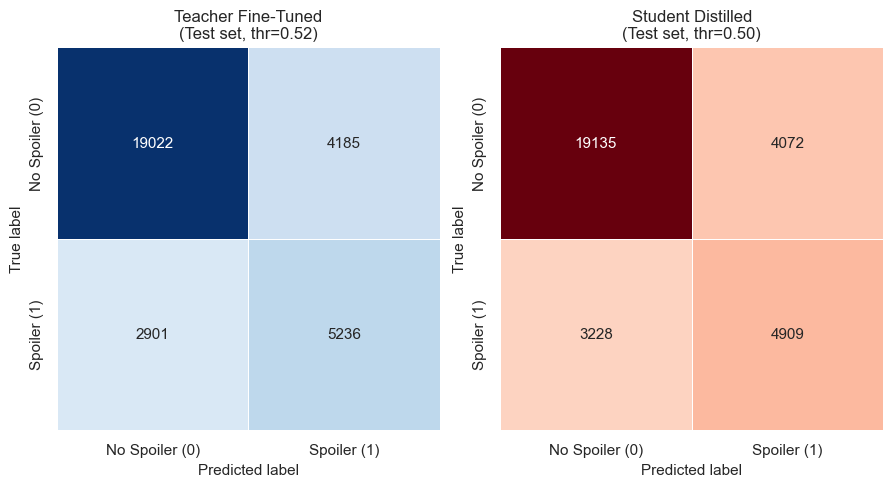

In [26]:
fig_cm_abs, axes_cm_abs = plot_confusion_matrices(
    results_dict=results,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_ft", "student_kd"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=11,
)
plt.show()

fig_cm_abs.savefig(FIG_DIR / "confusion_matrices_absolute.png", dpi=600)

## Plot 2: Bar char with all evaluation metrics for both the models

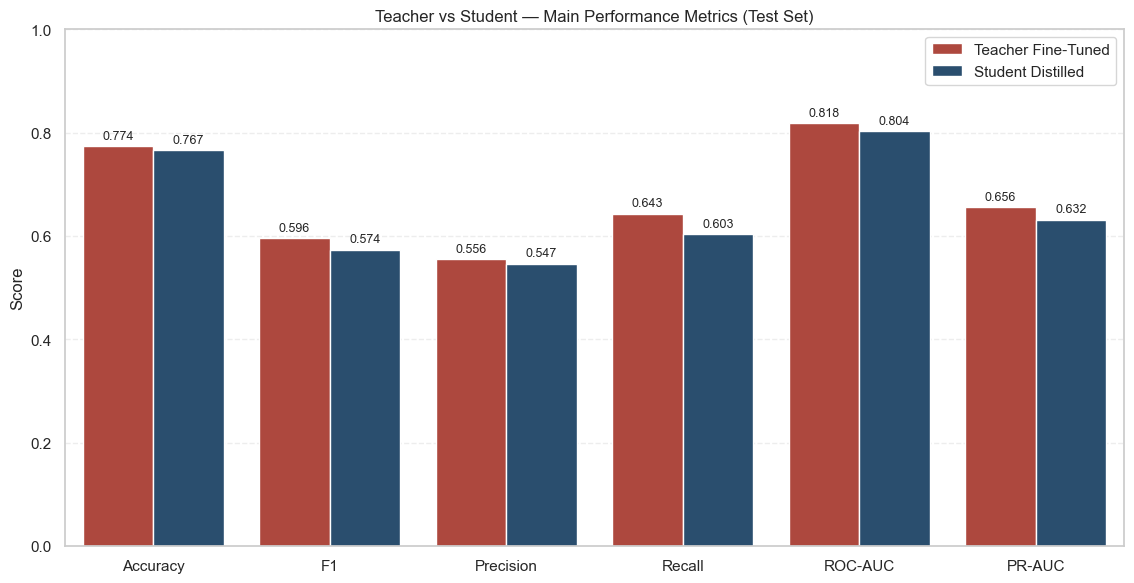

In [24]:
fig_bar_full, ax_bar_full = plot_metrics_barchart(
    df_metrics=df_metrics,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_ft", "student_kd"),
    figsize=(11.5, 6),
    y_lim=(0.0, 1.0),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
)
plt.show()

fig_bar_full.savefig(FIG_DIR / "metrics_barchart.png", dpi=600)